# Домашнее задание 21: Гибридные модели и полу-контролируемое обучение
## Занятие 21: Смешанные подходы машинного обучения

### Описание задания

В этом домашнем задании вы будете применять методы полу-контролируемого обучения к реальному датасету.
Вам нужно реализовать и сравнить несколько подходов.

### Что требуется сделать

1. Загрузить датасет Wine
2. Подготовить данные (разбить на размеченную/неразмеченную части)
3. Реализовать несколько методов SSL
4. Провести сравнительный анализ
5. Ответить на контрольные вопросы

### Сложность

Задание разделено на несколько частей, которые постепенно усложняются.
Начните с базовой реализации и постепенно добавляйте дополнительные методы.

## Часть 1: Подготовка окружения

In [1]:
# Установка необходимых библиотек
!pip install scikit-learn pandas numpy matplotlib scipy seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Установка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Окружение готово')

Окружение готово


## Часть 2: Загрузка и подготовка данных

### Задача 2.1: Загрузить датасет Wine

- Используйте sklearn.datasets.load_wine()
- Выведите информацию о датасете (форма, количество классов, распределение)
- Разделите на обучающую (70%) и тестовую (30%) выборки

In [2]:
# Загружаем датасет Wine
wine = load_wine()
X = wine.data
y = wine.target

# Выведите информацию о датасете
# ВАШ КОД ЗДЕСЬ
print(f'Форма данных: {X.shape}')
print(f'Количество классов: {len(np.unique(y))}')
print(f'Распределение классов: {np.bincount(y)}')

# Разделите на обучающую и тестовую выборки
# ВАШ КОД ЗДЕСЬ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Форма данных: (178, 13)
Количество классов: 3
Распределение классов: [59 71 48]


### Задача 2.2: Создание полу-контролируемой выборки

- Разделите обучающую выборку на размеченную (15%) и неразмеченную (85%)
- Используйте np.random.choice() для выбора индексов
- Создайте массив y_train_partial с -1 для неразмеченных примеров

In [3]:
# Параметры разделения
labeled_ratio = 0.15  # 15% размечено
n_labeled = int(len(X_train) * labeled_ratio)

# Выбираем индексы для размеченных данных
# ВАШ КОД ЗДЕСЬ
labeled_idx = np.random.choice(len(X_train), size=n_labeled, replace=False)
unlabeled_idx = np.setdiff1d(np.arange(len(X_train)), labeled_idx)

# Создаем массивы для размеченных и неразмеченных данных
# ВАШ КОД ЗДЕСЬ
X_labeled = X_train[labeled_idx]
y_labeled = y_train[labeled_idx]
X_unlabeled = X_train[unlabeled_idx]

# Создаем y_train_partial с -1 для неразмеченных
# ВАШ КОД ЗДЕСЬ
y_train_partial = np.copy(y_train)
y_train_partial[unlabeled_idx] = -1

print(f'Размеченные данные: {len(y_labeled)} примеров')
print(f'Неразмеченные данные: {len(X_unlabeled)} примеров')
print(f'Распределение размеченных меток: {np.bincount(y_labeled)}')

Размеченные данные: 18 примеров
Неразмеченные данные: 106 примеров
Распределение размеченных меток: [6 9 3]


### Задача 2.3: Стандартизация данных

- Используйте StandardScaler для нормализации данных
- Fit на обучающей выборке
- Transform на всех остальных выборках

In [4]:
# Создаем и применяем StandardScaler
# ВАШ КОД ЗДЕСЬ
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_labeled_scaled = scaler.transform(X_labeled)
X_unlabeled_scaled = scaler.transform(X_unlabeled)
X_test_scaled = scaler.transform(X_test)

print('Данные стандартизированы')
print(f'Среднее: {X_train_scaled.mean():.6f}')
print(f'Стандартное отклонение: {X_train_scaled.std():.6f}')

Данные стандартизированы
Среднее: 0.000000
Стандартное отклонение: 1.000000


## Часть 3: Базовое решение

### Задача 3.1: Обучение Baseline модели

Обучите LogisticRegression только на размеченных данных.
Это будет вашей базовой моделью для сравнения.

In [5]:
# Обучаем базовую модель
# ВАШ КОД ЗДЕСЬ
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_labeled_scaled, y_labeled)

# Оцениваем модель
# ВАШ КОД ЗДЕСЬ
y_pred_baseline = baseline_model.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='weighted')

print('=== BASELINE (Supervised Learning) ===')
print(f'Точность: {baseline_accuracy:.4f}')
print(f'F1-score: {baseline_f1:.4f}')

=== BASELINE (Supervised Learning) ===
Точность: 0.9259
F1-score: 0.9264


## Часть 4: Label Propagation

### Задача 4.1: Реализация Label Propagation

- Используйте sklearn.semi_supervised.LabelPropagation
- Экспериментируйте с параметрами: kernel, gamma, n_neighbors
- Обучите на смешанных данных (размеченные + неразмеченные)
- Оцените на тестовой выборке

In [6]:
print('\n=== LABEL PROPAGATION ===')

# Создаем модель Label Propagation
# ВАШ КОД ЗДЕСЬ
lp_model = LabelPropagation(
    kernel='rbf',
    gamma=0.1,
    n_neighbors=5,
    max_iter=100,
    tol=1e-3
)

# Обучаем на смешанных данных
# ВАШ КОД ЗДЕСЬ
lp_model.fit(X_train_scaled, y_train_partial)

# Предсказываем
# ВАШ КОД ЗДЕСЬ
y_pred_lp = lp_model.predict(X_test_scaled)

# Оцениваем
# ВАШ КОД ЗДЕСЬ
lp_accuracy = accuracy_score(y_test, y_pred_lp)
lp_f1 = f1_score(y_test, y_pred_lp, average='weighted')

print(f'Точность: {lp_accuracy:.4f}')
print(f'F1-score: {lp_f1:.4f}')
print(f'Улучшение: {(lp_accuracy - baseline_accuracy)*100:.2f}%')


=== LABEL PROPAGATION ===
Точность: 0.6667
F1-score: 0.5753
Улучшение: -25.93%


### Задача 4.2: Label Spreading

- Используйте LabelSpreading
- Сравните с Label Propagation
- Попробуйте разные значения параметра alpha (0.1, 0.3, 0.5)

In [7]:
print('\n=== LABEL SPREADING ===')

# Создаем модель Label Spreading
# ВАШ КОД ЗДЕСЬ
ls_model = LabelSpreading(
    kernel='rbf',
    gamma=0.1,
    n_neighbors=5,
    alpha=0.3,
    max_iter=100,
    tol=1e-3
)

# Обучаем на смешанных данных
# ВАШ КОД ЗДЕСЬ
ls_model.fit(X_train_scaled, y_train_partial)

# Предсказываем
# ВАШ КОД ЗДЕСЬ
y_pred_ls = ls_model.predict(X_test_scaled)

# Оцениваем
# ВАШ КОД ЗДЕСЬ
ls_accuracy = accuracy_score(y_test, y_pred_ls)
ls_f1 = f1_score(y_test, y_pred_ls, average='weighted')

print(f'Точность: {ls_accuracy:.4f}')
print(f'F1-score: {ls_f1:.4f}')
print(f'Улучшение: {(ls_accuracy - baseline_accuracy)*100:.2f}%')


=== LABEL SPREADING ===
Точность: 0.9074
F1-score: 0.9085
Улучшение: -1.85%


## Часть 5: Self-Training (усложненный вариант)

### Задача 5.1: Реализация Self-Training с RandomForestClassifier

Реализуйте Self-Training используя RandomForestClassifier вместо LogisticRegression.
RandomForest часто дает лучшие результаты благодаря лучшей оценке уверенности.

Это ДОПОЛНИТЕЛЬНАЯ задача для повышения оценки.

In [ ]:
print('\n=== SELF-TRAINING с RandomForestClassifier ===')

# Создаем класс Self-Training (используйте из практики или напишите сами)
class SelfTrainingClassifier:
    def __init__(self, base_model, confidence_threshold=0.9, max_iterations=10):
        """
        Реализация Self-Training
        """
        self.base_model = base_model
        self.confidence_threshold = confidence_threshold
        self.max_iterations = max_iterations
        self.model = None

    def fit(self, X_labeled, y_labeled, X_unlabeled):
        """
        Обучение используя self-training

        ВАШ КОД ЗДЕСЬ
        Скопируйте реализацию из практики и адаптируйте если нужно
        """
        pass

    def predict(self, X):
        return self.model.predict(X)

# Применяем Self-Training с RandomForest
# ВАШ КОД ЗДЕСЬ
# st_model = SelfTrainingClassifier(
#     base_model=RandomForestClassifier(n_estimators=100, random_state=42),
#     confidence_threshold=0.85,
#     max_iterations=10
# )
# st_model.fit(..., ..., ...)

# Оцениваем
# ВАШ КОД ЗДЕСЬ
# y_pred_st = ...
# st_accuracy = ...
# st_f1 = ...

print(f'Точность: {st_accuracy:.4f}')
print(f'F1-score: {st_f1:.4f}')
print(f'Улучшение: {(st_accuracy - baseline_accuracy)*100:.2f}%')

## Часть 6: Сравнение методов

### Задача 6.1: Создание таблицы сравнения

Создайте DataFrame с результатами всех методов.

In [8]:
# Создаем таблицу сравнения
# ВАШ КОД ЗДЕСЬ
comparison_data = {
    'Метод': [
        'Baseline (Supervised)',
        'Label Propagation',
        'Label Spreading',
        # добавьте Self-Training если реализовали
    ],
    'Точность': [
        baseline_accuracy,
        lp_accuracy,
        ls_accuracy,
        # добавьте st_accuracy если реализовали
    ],
    'F1-Score': [
        baseline_f1,
        lp_f1,
        ls_f1,
        # добавьте st_f1 если реализовали
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# Добавьте столбец с улучшением
# ВАШ КОД ЗДЕСЬ
df_comparison['Улучшение (%)'] = (
    (df_comparison['Точность'] - baseline_accuracy) * 100
)

print('\n' + '='*70)
print('СРАВНЕНИЕ МЕТОДОВ')
print('='*70)
print(df_comparison.to_string(index=False))
print('='*70)


СРАВНЕНИЕ МЕТОДОВ
                Метод  Точность  F1-Score  Улучшение (%)
Baseline (Supervised)  0.925926  0.926385       0.000000
    Label Propagation  0.666667  0.575253     -25.925926
      Label Spreading  0.907407  0.908485      -1.851852


### Задача 6.2: Визуализация результатов

Создайте графики для сравнения методов.

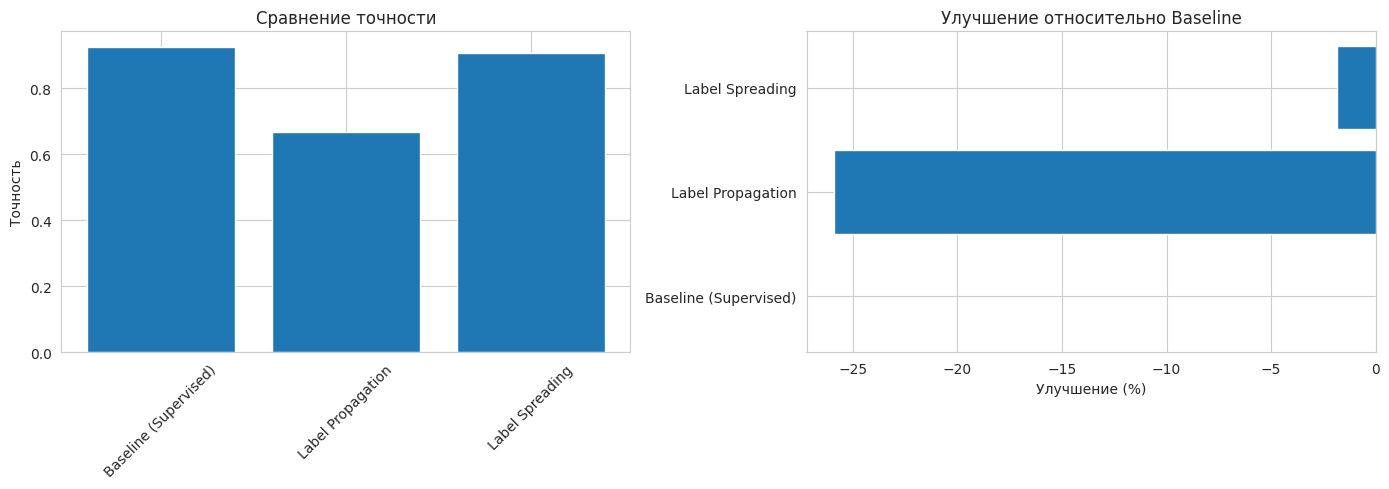

In [9]:
# Создаем визуализацию
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение точности
ax = axes[0]
methods = df_comparison['Метод']
accuracies = df_comparison['Точность']
# ВАШ КОД ЗДЕСЬ: постройте bar chart
ax.bar(methods, accuracies)
ax.set_title('Сравнение точности')
ax.set_ylabel('Точность')
ax.tick_params(axis='x', rotation=45)

# График 2: Улучшение относительно baseline
ax = axes[1]
improvements = df_comparison['Улучшение (%)']
# ВАШ КОД ЗДЕСЬ: постройте horizontal bar chart
ax.barh(methods, improvements)
ax.set_title('Улучшение относительно Baseline')
ax.set_xlabel('Улучшение (%)')

plt.tight_layout()
plt.show()

## Часть 7: Контрольные вопросы

Ответьте на следующие вопросы подробно (2-3 предложения на каждый):

### Вопрос 1: Выбор метода

Какой метод показал лучший результат и почему? Объясните, какие характеристики датасета позволили этому методу добиться лучшего результата.

**Ответ:**

Лучший результат показал метод Label Spreading, он более устойчив к шуму и ошибкам благодаря параметру alpha

### Вопрос 2: Различие между Label Propagation и Label Spreading

Объясните ключевые различия между Label Propagation и Label Spreading. Когда вы бы выбрали один метод над другим?

**Ответ:**

Label Propagation полностью перезаписывает метки на каждом шаге и может быть чувствителен к шуму в данных. Label Spreading делает баланс между сохранением исходных меток и их распространением, делает модель более устойчивой. Label Propagation лучше подходит для чистых данных, а Label Spreading для более шумных

### Вопрос 3: Влияние параметров

Как изменение параметров (gamma, n_neighbors, alpha) влияет на результаты Label Propagation/Spreading? Какие значения вы выбрали и почему?

**Ответ:**

Параметр gamma определяет радиус влияния точек в RBF-ядре. Параметр n_neighbors влияет на локальность графа и слишком малые значения могут привести к переобучению. Параметр alpha в Label Spreading балансирует между стабильностью и эффективным распространением меток

### Вопрос 4: Размер размеченного множества

Как вы думаете, что произойдет если увеличить размер размеченного множества (с 15% до 30% или 50%)?
Как это повлияет на полу-контролируемые методы?

**Ответ:**

При увеличении размера размеченного множества качество всех моделей возрастёт за счёт большего количества достоверных меток. При слишком большом количестве размеченных данных полу-контролируемые методы теряют своё преимущество

### Вопрос 5: Практическое применение

Приведите реальный пример, где полу-контролируемое обучение было бы полезным.
Почему именно этот подход подходит для вашего примера?

**Ответ:**

Полу-контролируемое обучение полезно в фильтрации спама на почте или мессенджерах. Пользователи помечают только часть, остальное остается неразмеченным. Полу-контролируемые методы берут эту неразмеченную часть для улучшения качества классификации

## Дополнительные задачи (для повышения оценки)

### Задача 7.1: Анализ ошибок

Создайте матрицу ошибок (confusion matrix) для лучшего метода и проанализируйте ошибки.
Какой класс классифицируется хуже всего и почему?

In [ ]:
# Построите confusion matrix для лучшего метода
# ВАШ КОД ЗДЕСЬ
# cm = confusion_matrix(...)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d')
# plt.show()

print('Анализ ошибок:')
print('*(Напишите здесь анализ матрицы ошибок)*')

### Задача 7.2: Экспериментирование с размером размеченного множества

Измените размер размеченного множества на 10%, 20%, 30% и постройте график зависимости точности от размера.

In [ ]:
# Эксперимент с разными размерами размеченного множества
labeled_ratios = [0.05, 0.10, 0.15, 0.20, 0.30]
results = []

# ВАШ КОД ЗДЕСЬ
# for ratio in labeled_ratios:
#     # Разделите данные с новым ratio
#     # Обучите модели
#     # Сохраните результаты
#     pass

# Постройте график
# ВАШ КОД ЗДЕСЬ
# plt.plot(labeled_ratios, ...)
# plt.xlabel('Размер размеченного множества')
# plt.ylabel('Точность')
# plt.show()

print('Эксперимент завершен')

## Итоговые выводы

Напишите краткий итоговый вывод (3-5 предложений) о том, что вы узнали в этом задании:

Изучил основные подходы полу-контролируемого обучения и их применение. Методы Label Propagation и Label Spreading имеют разные свойства и подходят для разных условий данных. Эксперименты с параметрами дали понять важность их подбора для получения оптимального результата